# Exploración del subcorpus: cuartetos de cuerda y *Canzoni per sonar a quattro*

Este notebook explora conjuntamente:

1. El subcorpus de cuartetos de cuerda seleccionado:
   - núcleo clásico: Haydn, Mozart y Beethoven;
   - extensión romántica: Schumann, Brahms y Dvořák;
   - casos externos: Debussy y Shostakovich.
2. Las cuatro *Canzoni per sonar a quattro* de Giovanni Gabrieli.


- ¿Qué obras contiene el subcorpus?
- ¿A qué periodos pertenecen?
- ¿Qué instrumentos o roles tienen sus cuatro voces?
- ¿Cuántas notas contiene cada voz?
- ¿Las secuencias representan movimientos separados o obras completas?

## Información musicológica de Gabrieli

La colección contiene cuatro piezas:

1. **Canzon prima “La Spiritata”, Ch.186**
2. **Canzon seconda, Ch.187**
3. **Canzon terza, Ch.188**
4. **Canzon quarta, Ch.189**

Fue publicada en 1608. IMSLP la clasifica dentro del Renacimiento y señala una
instrumentación abierta para cuatro instrumentos: dos partes agudas, tenor y bajo.
Para este proyecto se utiliza la etiqueta transicional
**Renacimiento tardío / Barroco temprano**, porque funciona como antecedente
histórico del ensamble instrumental a cuatro partes.

Fuentes:

- https://imslp.org/wiki/Canzoni_per_sonar_a_quattro_(Gabrieli,_Giovanni)
- https://imslp.org/wiki/Canzon_I_%27La_Spiritata%27,_Ch.186_(Gabrieli,_Giovanni)

In [2]:
from pathlib import Path
import json
import math
import struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Audio, FileLink, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

DATA_DIRS = [Path.cwd(), Path("/mnt/data")]

def find_latest_csv(pattern):
    candidates = []
    for directory in DATA_DIRS:
        candidates.extend(directory.glob(pattern))
    candidates = sorted(
        {path.resolve() for path in candidates if path.exists()},
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No se encontró ningún archivo que coincida con {pattern!r} "
            f"en {[str(d) for d in DATA_DIRS]}."
        )
    return candidates[0]

quartet_path = find_latest_csv("quartet_subcorpus_works*.csv")
gabrieli_path = find_latest_csv("gabrieli_canzoni_per_sonar_a_quattro*.csv")

print("CSV de cuartetos:", quartet_path)
print("CSV de Gabrieli:", gabrieli_path)

CSV de cuartetos: C:\Users\PC BULLOCK\Downloads\quartet_subcorpus_works.csv
CSV de Gabrieli: C:\Users\PC BULLOCK\Downloads\gabrieli_canzoni_per_sonar_a_quattro.csv


In [3]:
quartets = pd.read_csv(quartet_path)
gabrieli = pd.read_csv(gabrieli_path)

print(f"Cuartetos: {quartets.shape[0]} obras × {quartets.shape[1]} columnas")
print(f"Gabrieli: {gabrieli.shape[0]} obras × {gabrieli.shape[1]} columnas")

display(pd.DataFrame({
    "archivo": [quartet_path.name, gabrieli_path.name],
    "filas": [len(quartets), len(gabrieli)],
    "columnas": [quartets.shape[1], gabrieli.shape[1]],
}))

Cuartetos: 29 obras × 29 columnas
Gabrieli: 4 obras × 21 columnas


,archivo,filas,columnas
0,quartet_subcorpus_works.csv,29,29
1,gabrieli_canzoni_per_sonar_a_quattro.csv,4,21


## 1. Validación de `voices_pitches`

Cada celda debe ser un arreglo JSON con cuatro listas internas. Se comprobará:

- que el JSON sea válido;
- que cada obra tenga cuatro voces;
- que las longitudes calculadas coincidan con las columnas almacenadas;
- que todos los valores sean alturas MIDI entre 0 y 127.

In [4]:
def parse_voices(value, work_id):
    try:
        voices = json.loads(value)
    except Exception as exc:
        raise ValueError(f"JSON inválido en {work_id}: {exc}") from exc

    if not isinstance(voices, list) or len(voices) != 4:
        raise ValueError(f"{work_id}: se esperaban 4 voces y se encontraron {len(voices)}.")

    for i, voice in enumerate(voices):
        if not isinstance(voice, list):
            raise TypeError(f"{work_id}, voz {i}: no es una lista.")
        invalid = [pitch for pitch in voice if not isinstance(pitch, (int, float)) or not 0 <= pitch <= 127]
        if invalid:
            raise ValueError(f"{work_id}, voz {i}: alturas MIDI inválidas: {invalid[:5]}")
    return [[int(round(pitch)) for pitch in voice] for voice in voices]

quartets["voices"] = [
    parse_voices(value, work_id)
    for value, work_id in zip(quartets["voices_pitches"], quartets["work_id"])
]
gabrieli["voices"] = [
    parse_voices(value, work_id)
    for value, work_id in zip(gabrieli["voices_pitches"], gabrieli["work_id"])
]

quartet_length_columns = ["vln_I_len", "vln_II_len", "viola_len", "cello_len"]

quartet_checks = []
for _, row in quartets.iterrows():
    calculated = [len(v) for v in row["voices"]]
    stored = [int(row[col]) for col in quartet_length_columns]
    quartet_checks.append(calculated == stored)

gabrieli_checks = []
for _, row in gabrieli.iterrows():
    lengths = [len(v) for v in row["voices"]]
    gabrieli_checks.append(
        min(lengths) == int(row["min_len"])
        and max(lengths) == int(row["max_len"])
        and np.isclose(np.mean(lengths), float(row["mean_len"]), atol=0.11)
    )

validation = pd.DataFrame({
    "corpus": ["Cuartetos", "Gabrieli"],
    "obras": [len(quartets), len(gabrieli)],
    "JSON_y_número_de_voces_válidos": [True, True],
    "longitudes_coinciden": [all(quartet_checks), all(gabrieli_checks)],
})
display(validation)

assert all(quartet_checks)
assert all(gabrieli_checks)

,corpus,obras,JSON_y_número_de_voces_válidos,longitudes_coinciden
0,Cuartetos,29,True,True
1,Gabrieli,4,True,True


## 2. Armonización de metadatos

Se construirá una tabla común con una fila por obra. Para Gabrieli añadimos los
títulos y números de catálogo Ch.186–Ch.189. Para los cuartetos se conservan los
metadatos ya curados en `quartet_subcorpus_works.csv`.

In [5]:
gabrieli_titles = {
    1: ("Canzon prima 'La Spiritata'", "Ch.186"),
    2: ("Canzon seconda", "Ch.187"),
    3: ("Canzon terza", "Ch.188"),
    4: ("Canzon quarta", "Ch.189"),
}

gabrieli["work_title"] = gabrieli["canzona_no"].map(
    lambda n: gabrieli_titles[int(n)][0]
)
gabrieli["catalogue"] = gabrieli["canzona_no"].map(
    lambda n: gabrieli_titles[int(n)][1]
)

def quartet_boundary_description(row):
    if row["source_file_unit"] == "movement":
        return (
            f"{int(row['n_source_files'])} archivos de movimiento concatenados "
            "por instrumento; voices_pitches no conserva separadores."
        )
    if row["source_file_unit"] == "complete_work":
        return (
            "Un único MIDI de obra completa; voices_pitches es un solo array por "
            "instrumento y no contiene marcas internas de movimiento."
        )
    return "Unidad de fuente no determinada."

quartet_overview = quartets.assign(
    collection=quartets["work_title"],
    array_content="obra completa por voz",
    boundary_information=quartets.apply(quartet_boundary_description, axis=1),
)[[
    "work_id", "composer_canonical", "work_title", "catalogue", "period",
    "genre", "instrumentation", "corpus_group", "source_file_unit",
    "n_source_files", "n_movements_available", "is_complete",
    "array_content", "boundary_information"
]].copy()

gabrieli_overview = pd.DataFrame({
    "work_id": gabrieli["work_id"],
    "composer_canonical": gabrieli["composer_canonical"],
    "work_title": gabrieli["work_title"],
    "catalogue": gabrieli["catalogue"],
    "period": gabrieli["period"],
    "genre": gabrieli["genre"],
    "instrumentation": "4 instrumentos de timbre abierto: 2 partes agudas, tenor y bajo",
    "corpus_group": gabrieli["corpus_group"],
    "source_file_unit": "complete_one_movement_work",
    "n_source_files": 1,
    "n_movements_available": 1,
    "is_complete": True,
    "array_content": "canzona completa por voz",
    "boundary_information": (
        "Cada fila es una canzona completa de un solo movimiento; no se requieren "
        "separadores internos."
    ),
})

works_overview = pd.concat([quartet_overview, gabrieli_overview], ignore_index=True)

print(f"Total: {len(works_overview)} obras")
display(works_overview)

Total: 33 obras


,work_id,composer_canonical,work_title,catalogue,period,genre,instrumentation,corpus_group,source_file_unit,n_source_files,n_movements_available,is_complete,array_content,boundary_information
0,haydn_op20_no1,Joseph Haydn,String Quartet Op. 20 No. 1,Op. 20 No. 1,Classical,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
1,haydn_op20_no2,Joseph Haydn,String Quartet Op. 20 No. 2,Op. 20 No. 2,Classical,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
2,haydn_op20_no3,Joseph Haydn,String Quartet Op. 20 No. 3,Op. 20 No. 3,Classical,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
3,haydn_op20_no4,Joseph Haydn,String Quartet Op. 20 No. 4,Op. 20 No. 4,Classical,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
4,haydn_op20_no5,Joseph Haydn,String Quartet Op. 20 No. 5,Op. 20 No. 5,Classical,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
5,haydn_op20_no6,Joseph Haydn,String Quartet Op. 20 No. 6,Op. 20 No. 6,Classical,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
6,beethoven_op18_no1,Ludwig van Beethoven,String Quartet Op. 18 No. 1,Op. 18 No. 1,Classical / transitional,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
7,beethoven_op18_no2,Ludwig van Beethoven,String Quartet Op. 18 No. 2,Op. 18 No. 2,Classical / transitional,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
8,beethoven_op18_no3,Ludwig van Beethoven,String Quartet Op. 18 No. 3,Op. 18 No. 3,Classical / transitional,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.
9,beethoven_op18_no4,Ludwig van Beethoven,String Quartet Op. 18 No. 4,Op. 18 No. 4,Classical / transitional,string_quartet,2vn-va-vc,classical_core,movement,4,4.0,True,obra completa por voz,4 archivos de movimiento concatenados por instrumento; voices_pitches no conserva separadores.


## 3. ¿Qué piezas contiene el subcorpus?

La tabla siguiente presenta todas las obras, agrupadas por compositor y colección
analítica. El núcleo clásico está balanceado con seis obras por compositor:

- Haydn: seis cuartetos Op.20;
- Mozart: seis cuartetos dedicados a Haydn;
- Beethoven: seis cuartetos Op.18.

La extensión romántica contiene tres obras por compositor:

- Schumann;
- Brahms;
- Dvořák.

Debussy y Shostakovich se conservan como casos externos, mientras que Gabrieli
forma la extensión histórica temprana.

## 4. Periodos representados

Las etiquetas se interpretan como categorías analíticas, no como fronteras
históricas absolutas:

- **Renacimiento tardío / Barroco temprano:** Gabrieli;
- **Clasicismo:** Haydn y Mozart;
- **Clasicismo / transición:** Beethoven Op.18;
- **Romanticismo:** Schumann, Brahms y Dvořák;
- **Fin del siglo XIX:** Debussy;
- **Siglo XX:** Shostakovich.

Gabrieli está etiquetado como periodo transicional para el proyecto, aunque la
fuente de catálogo de IMSLP clasifica la colección como renacentista.

,n_obras
period,
20th century,1
Late 19th century / fin-de-siècle,1
Late Renaissance / Early Baroque,4
Classical / transitional,6
Romantic,9
Classical,12


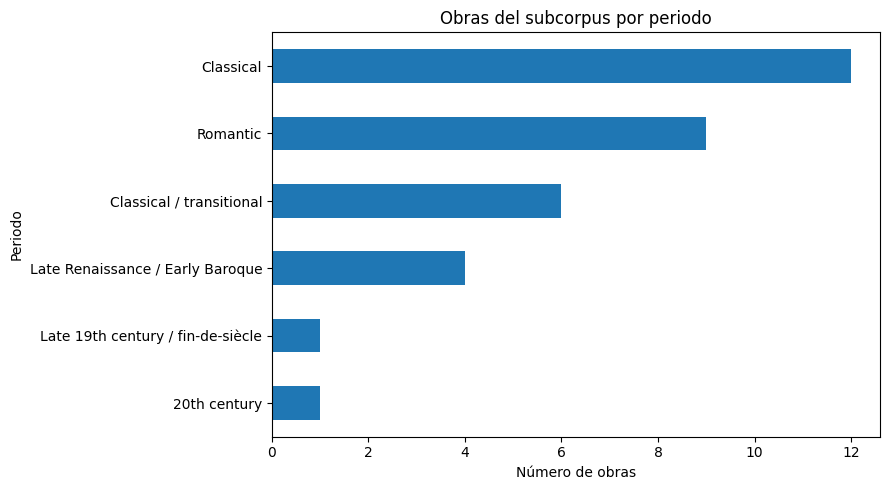

In [6]:
period_counts = (
    works_overview.groupby("period")
    .size()
    .sort_values()
)

display(period_counts.rename("n_obras").to_frame())

plt.figure(figsize=(9, 5))
period_counts.plot(kind="barh")
plt.xlabel("Número de obras")
plt.ylabel("Periodo")
plt.title("Obras del subcorpus por periodo")
plt.tight_layout()
plt.show()

## 5. Instrumentos y roles de las voces

### Cuartetos

La correspondencia es instrumental y estable:

1. violín I;
2. violín II;
3. viola;
4. cello.

### Gabrieli

La colección tiene instrumentación abierta. El CSV permite estudiar cuatro
partes registrales:

1. parte aguda 1;
2. parte aguda 2;
3. tenor;
4. bajo.

Estas etiquetas no identifican necesariamente violín, corneta, trombón, viola da
gamba u otro timbre específico. 

In [7]:
voice_role_reference = pd.DataFrame([
    {
        "corpus": "Cuartetos de cuerda",
        "voice_index": 0,
        "role": "vln_I",
        "nombre": "Violín I",
        "tipo": "instrumento identificado",
    },
    {
        "corpus": "Cuartetos de cuerda",
        "voice_index": 1,
        "role": "vln_II",
        "nombre": "Violín II",
        "tipo": "instrumento identificado",
    },
    {
        "corpus": "Cuartetos de cuerda",
        "voice_index": 2,
        "role": "viola",
        "nombre": "Viola",
        "tipo": "instrumento identificado",
    },
    {
        "corpus": "Cuartetos de cuerda",
        "voice_index": 3,
        "role": "cello",
        "nombre": "Cello",
        "tipo": "instrumento identificado",
    },
    {
        "corpus": "Gabrieli",
        "voice_index": 0,
        "role": "upper_1",
        "nombre": "Parte aguda 1",
        "tipo": "rol registral; timbre abierto",
    },
    {
        "corpus": "Gabrieli",
        "voice_index": 1,
        "role": "upper_2",
        "nombre": "Parte aguda 2",
        "tipo": "rol registral; timbre abierto",
    },
    {
        "corpus": "Gabrieli",
        "voice_index": 2,
        "role": "tenor",
        "nombre": "Tenor",
        "tipo": "rol registral; timbre abierto",
    },
    {
        "corpus": "Gabrieli",
        "voice_index": 3,
        "role": "bass",
        "nombre": "Bajo",
        "tipo": "rol registral; timbre abierto",
    },
])

display(voice_role_reference)

,corpus,voice_index,role,nombre,tipo
0,Cuartetos de cuerda,0,vln_I,Violín I,instrumento identificado
1,Cuartetos de cuerda,1,vln_II,Violín II,instrumento identificado
2,Cuartetos de cuerda,2,viola,Viola,instrumento identificado
3,Cuartetos de cuerda,3,cello,Cello,instrumento identificado
4,Gabrieli,0,upper_1,Parte aguda 1,rol registral; timbre abierto
5,Gabrieli,1,upper_2,Parte aguda 2,rol registral; timbre abierto
6,Gabrieli,2,tenor,Tenor,rol registral; timbre abierto
7,Gabrieli,3,bass,Bajo,rol registral; timbre abierto


## 6. ¿Son movimientos o obras completas?

Hay que separar dos conceptos:

### Unidad de los archivos originales

- `source_file_unit == "movement"`: la obra se construyó a partir de varios MIDI,
  uno por movimiento.
- `source_file_unit == "complete_work"`: un único MIDI contenía la obra completa.
- En Gabrieli cada archivo contiene una canzona completa, que es una pieza de un
  solo movimiento.

### Unidad de `voices_pitches`

En `quartet_subcorpus_works.csv`, cada fila ya representa una **obra completa**.
Cuando la fuente estaba separada por movimientos, estos fueron concatenados por
instrumento:

$$
X_r = X_r^{(1)} \Vert X_r^{(2)} \Vert \cdots \Vert X_r^{(K)}.
$$

El array final no contiene delimitadores entre movimientos. En obras procedentes
de un único MIDI completo tampoco hay índices internos que identifiquen los
cambios de movimiento.

Por tanto, para recuperar fronteras exactas habría que conservar las longitudes
de cada movimiento desde el CSV por archivo o volver a los MIDI originales.

In [8]:
source_unit_summary = (
    works_overview.groupby(
        ["corpus_group", "source_file_unit", "array_content"],
        dropna=False
    )
    .size()
    .rename("n_obras")
    .reset_index()
)

display(source_unit_summary)

display(
    works_overview[[
        "composer_canonical", "work_title", "catalogue",
        "source_file_unit", "n_source_files", "n_movements_available",
        "array_content", "boundary_information"
    ]].sort_values(["source_file_unit", "composer_canonical", "catalogue"])
)

,corpus_group,source_file_unit,array_content,n_obras
0,baroque_extension,complete_one_movement_work,canzona completa por voz,4
1,classical_core,movement,obra completa por voz,18
2,modern_case_study,complete_work,obra completa por voz,1
3,modern_case_study,movement,obra completa por voz,1
4,romantic_extension,complete_work,obra completa por voz,9


,composer_canonical,work_title,catalogue,source_file_unit,n_source_files,n_movements_available,array_content,boundary_information
29,Giovanni Gabrieli,Canzon prima 'La Spiritata',Ch.186,complete_one_movement_work,1,1.0,canzona completa por voz,Cada fila es una canzona completa de un solo movimiento; no se requieren separadores internos.
30,Giovanni Gabrieli,Canzon seconda,Ch.187,complete_one_movement_work,1,1.0,canzona completa por voz,Cada fila es una canzona completa de un solo movimiento; no se requieren separadores internos.
31,Giovanni Gabrieli,Canzon terza,Ch.188,complete_one_movement_work,1,1.0,canzona completa por voz,Cada fila es una canzona completa de un solo movimiento; no se requieren separadores internos.
32,Giovanni Gabrieli,Canzon quarta,Ch.189,complete_one_movement_work,1,1.0,canzona completa por voz,Cada fila es una canzona completa de un solo movimiento; no se requieren separadores internos.
20,Antonín Dvořák,String Quartet Op. 105,Op. 105,complete_work,1,NaN,obra completa por voz,Un único MIDI de obra completa; voices_pitches es un solo array por instrumento y no contiene marcas internas de mov...
21,Antonín Dvořák,String Quartet Op. 51,Op. 51,complete_work,1,NaN,obra completa por voz,Un único MIDI de obra completa; voices_pitches es un solo array por instrumento y no contiene marcas internas de mov...
22,Antonín Dvořák,String Quartet Op. 96,Op. 96,complete_work,1,NaN,obra completa por voz,Un único MIDI de obra completa; voices_pitches es un solo array por instrumento y no contiene marcas internas de mov...
18,Claude Debussy,String Quartet Op. 10,Op. 10,complete_work,1,NaN,obra completa por voz,Un único MIDI de obra completa; voices_pitches es un solo array por instrumento y no contiene marcas internas de mov...
23,Johannes Brahms,String Quartet Op. 51 No. 1,Op. 51 No. 1,complete_work,1,NaN,obra completa por voz,Un único MIDI de obra completa; voices_pitches es un solo array por instrumento y no contiene marcas internas de mov...
24,Johannes Brahms,String Quartet Op. 51 No. 2,Op. 51 No. 2,complete_work,1,NaN,obra completa por voz,Un único MIDI de obra completa; voices_pitches es un solo array por instrumento y no contiene marcas internas de mov...


## 7. Tabla larga de longitudes por voz

Se transforma cada obra en cuatro observaciones, una por instrumento o rol. Esto
facilita comparar:

- longitud absoluta;
- desigualdad entre voces;
- número de ventanas disponibles;
- diferencias por compositor y periodo.

In [9]:
quartet_roles = ["vln_I", "vln_II", "viola", "cello"]
gabrieli_roles = ["upper_1", "upper_2", "tenor", "bass"]

long_rows = []

for _, row in quartets.iterrows():
    for voice_index, (role, pitches) in enumerate(zip(quartet_roles, row["voices"])):
        long_rows.append({
            "work_id": row["work_id"],
            "composer": row["composer_canonical"],
            "work_title": row["work_title"],
            "catalogue": row["catalogue"],
            "period": row["period"],
            "corpus_group": row["corpus_group"],
            "source_file_unit": row["source_file_unit"],
            "voice_index": voice_index,
            "voice_role": role,
            "n_notes": len(pitches),
            "pitch_min": min(pitches),
            "pitch_max": max(pitches),
            "pitch_mean": np.mean(pitches),
            "pitch_std": np.std(pitches),
        })

for _, row in gabrieli.iterrows():
    for voice_index, (role, pitches) in enumerate(zip(gabrieli_roles, row["voices"])):
        long_rows.append({
            "work_id": row["work_id"],
            "composer": row["composer_canonical"],
            "work_title": row["work_title"],
            "catalogue": row["catalogue"],
            "period": row["period"],
            "corpus_group": row["corpus_group"],
            "source_file_unit": "complete_one_movement_work",
            "voice_index": voice_index,
            "voice_role": role,
            "n_notes": len(pitches),
            "pitch_min": min(pitches),
            "pitch_max": max(pitches),
            "pitch_mean": np.mean(pitches),
            "pitch_std": np.std(pitches),
        })

voice_lengths = pd.DataFrame(long_rows)

print(f"{voice_lengths['work_id'].nunique()} obras")
print(f"{len(voice_lengths)} secuencias de voz")
display(voice_lengths.head(12))

33 obras
132 secuencias de voz


,work_id,composer,work_title,catalogue,period,corpus_group,source_file_unit,voice_index,voice_role,n_notes,pitch_min,pitch_max,pitch_mean,pitch_std
0,haydn_op20_no1,Joseph Haydn,String Quartet Op. 20 No. 1,Op. 20 No. 1,Classical,classical_core,movement,0,vln_I,3157,55,91,71.500158,6.518492
1,haydn_op20_no1,Joseph Haydn,String Quartet Op. 20 No. 1,Op. 20 No. 1,Classical,classical_core,movement,1,vln_II,2186,55,84,66.328911,6.004288
2,haydn_op20_no1,Joseph Haydn,String Quartet Op. 20 No. 1,Op. 20 No. 1,Classical,classical_core,movement,2,viola,1992,48,77,61.095884,6.398602
3,haydn_op20_no1,Joseph Haydn,String Quartet Op. 20 No. 1,Op. 20 No. 1,Classical,classical_core,movement,3,cello,2146,36,70,51.212488,7.912355
4,haydn_op20_no2,Joseph Haydn,String Quartet Op. 20 No. 2,Op. 20 No. 2,Classical,classical_core,movement,0,vln_I,3722,55,96,74.404890,7.769773
5,haydn_op20_no2,Joseph Haydn,String Quartet Op. 20 No. 2,Op. 20 No. 2,Classical,classical_core,movement,1,vln_II,3050,55,85,68.845574,6.608198
6,haydn_op20_no2,Joseph Haydn,String Quartet Op. 20 No. 2,Op. 20 No. 2,Classical,classical_core,movement,2,viola,2790,48,79,62.374194,5.925987
7,haydn_op20_no2,Joseph Haydn,String Quartet Op. 20 No. 2,Op. 20 No. 2,Classical,classical_core,movement,3,cello,2123,36,69,55.238342,7.592588
8,haydn_op20_no3,Joseph Haydn,String Quartet Op. 20 No. 3,Op. 20 No. 3,Classical,classical_core,movement,0,vln_I,4496,55,91,72.429048,7.089404
9,haydn_op20_no3,Joseph Haydn,String Quartet Op. 20 No. 3,Op. 20 No. 3,Classical,classical_core,movement,1,vln_II,2956,55,86,66.567997,6.064530


In [10]:
length_summary = (
    voice_lengths.groupby(["corpus_group", "composer"])
    .agg(
        n_obras=("work_id", "nunique"),
        n_voces=("n_notes", "size"),
        longitud_minima=("n_notes", "min"),
        longitud_mediana=("n_notes", "median"),
        longitud_media=("n_notes", "mean"),
        longitud_maxima=("n_notes", "max"),
    )
    .reset_index()
    .sort_values(["corpus_group", "composer"])
)

display(length_summary)

,corpus_group,composer,n_obras,n_voces,longitud_minima,longitud_mediana,longitud_media,longitud_maxima
0,baroque_extension,Giovanni Gabrieli,4,16,151,236.5,242.500000,349
1,classical_core,Joseph Haydn,6,24,1698,2801.5,2942.833333,5164
2,classical_core,Ludwig van Beethoven,6,24,2057,3557.5,3717.541667,5889
3,classical_core,Wolfgang Amadeus Mozart,6,24,1318,2448.0,2446.958333,3680
4,modern_case_study,Claude Debussy,1,4,3747,4522.0,4504.000000,5225
5,modern_case_study,Dmitri Shostakovich,1,4,1178,1971.0,1776.500000,1986
6,romantic_extension,Antonín Dvořák,3,12,2997,4481.5,4331.833333,5038
7,romantic_extension,Johannes Brahms,3,12,3303,4406.0,4271.083333,5071
8,romantic_extension,Robert Schumann,3,12,2439,3923.5,3667.166667,4339


C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_15744\2506161530.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=composer_order, vert=False)


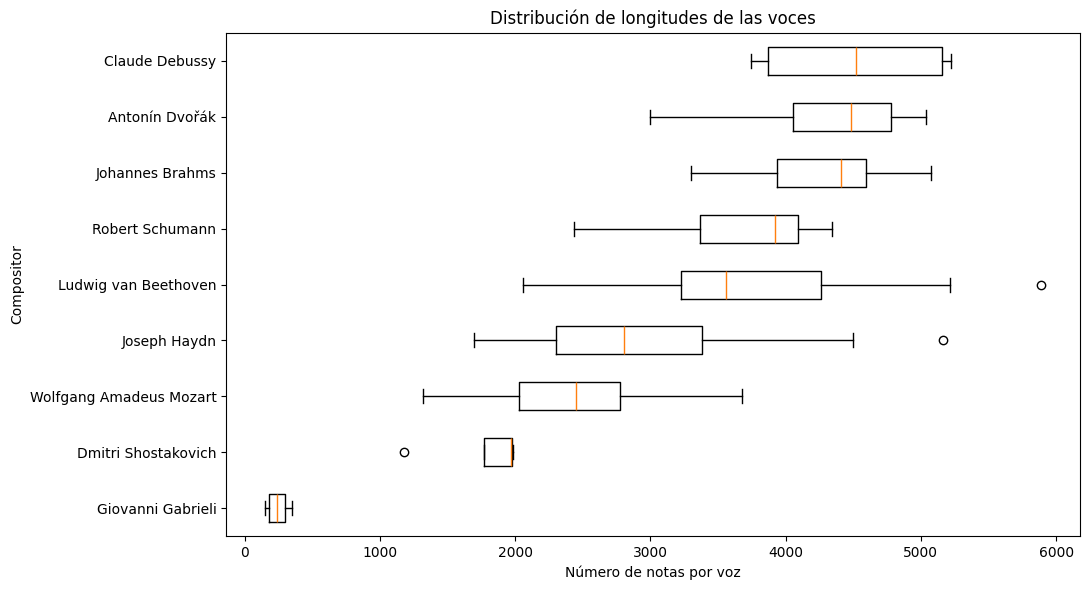

In [11]:
composer_order = (
    voice_lengths.groupby("composer")["n_notes"]
    .median()
    .sort_values()
    .index
)

data_for_boxplot = [
    voice_lengths.loc[voice_lengths["composer"] == composer, "n_notes"].to_numpy()
    for composer in composer_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(data_for_boxplot, labels=composer_order, vert=False)
plt.xlabel("Número de notas por voz")
plt.ylabel("Compositor")
plt.title("Distribución de longitudes de las voces")
plt.tight_layout()
plt.show()

## 8. Longitud de cada obra y desequilibrio entre voces

Además de la longitud mínima, calculamos:

\[
R_i = \frac{\max_r N_{i,r}}{\min_r N_{i,r}},
\]

donde \(R_i=1\) implicaría que las cuatro voces tienen exactamente el mismo número
de notas. Un valor grande indica diferencias de actividad entre voces, aunque no
necesariamente diferencias de duración temporal, porque el CSV no contiene
silencios ni valores rítmicos.

In [12]:
work_length_summary = (
    voice_lengths.groupby([
        "work_id", "composer", "work_title", "catalogue",
        "period", "corpus_group", "source_file_unit"
    ])
    .agg(
        min_voice_len=("n_notes", "min"),
        max_voice_len=("n_notes", "max"),
        mean_voice_len=("n_notes", "mean"),
        std_voice_len=("n_notes", "std"),
    )
    .reset_index()
)

work_length_summary["max_min_ratio"] = (
    work_length_summary["max_voice_len"] /
    work_length_summary["min_voice_len"]
)
work_length_summary["cv_voice_length"] = (
    work_length_summary["std_voice_len"] /
    work_length_summary["mean_voice_len"]
)

display(
    work_length_summary.sort_values(
        ["corpus_group", "composer", "catalogue"]
    ).reset_index(drop=True)
)

,work_id,composer,work_title,catalogue,period,corpus_group,source_file_unit,min_voice_len,max_voice_len,mean_voice_len,std_voice_len,max_min_ratio,cv_voice_length
0,gabrieli_canzoni_per_sonar_a_quattro_01,Giovanni Gabrieli,Canzon prima 'La Spiritata',Ch.186,Late Renaissance / Early Baroque,baroque_extension,complete_one_movement_work,235,349,308.25,52.645829,1.485106,0.170789
1,gabrieli_canzoni_per_sonar_a_quattro_02,Giovanni Gabrieli,Canzon seconda,Ch.187,Late Renaissance / Early Baroque,baroque_extension,complete_one_movement_work,259,303,284.75,20.369503,1.169884,0.071535
2,gabrieli_canzoni_per_sonar_a_quattro_03,Giovanni Gabrieli,Canzon terza,Ch.188,Late Renaissance / Early Baroque,baroque_extension,complete_one_movement_work,166,238,192.25,31.478829,1.433735,0.163739
3,gabrieli_canzoni_per_sonar_a_quattro_04,Giovanni Gabrieli,Canzon quarta,Ch.189,Late Renaissance / Early Baroque,baroque_extension,complete_one_movement_work,151,209,184.75,26.361272,1.384106,0.142686
4,haydn_op20_no1,Joseph Haydn,String Quartet Op. 20 No. 1,Op. 20 No. 1,Classical,classical_core,movement,1992,3157,2370.25,531.126084,1.584839,0.224080
5,haydn_op20_no2,Joseph Haydn,String Quartet Op. 20 No. 2,Op. 20 No. 2,Classical,classical_core,movement,2123,3722,2921.25,661.363932,1.753179,0.226398
6,haydn_op20_no3,Joseph Haydn,String Quartet Op. 20 No. 3,Op. 20 No. 3,Classical,classical_core,movement,2338,4496,3115.50,954.361741,1.923011,0.306327
7,haydn_op20_no4,Joseph Haydn,String Quartet Op. 20 No. 4,Op. 20 No. 4,Classical,classical_core,movement,2975,5164,3744.75,970.923744,1.735798,0.259276
8,haydn_op20_no5,Joseph Haydn,String Quartet Op. 20 No. 5,Op. 20 No. 5,Classical,classical_core,movement,2415,4126,2947.75,806.457015,1.708489,0.273584
9,haydn_op20_no6,Joseph Haydn,String Quartet Op. 20 No. 6,Op. 20 No. 6,Classical,classical_core,movement,1698,3719,2557.50,889.225318,2.190224,0.347693


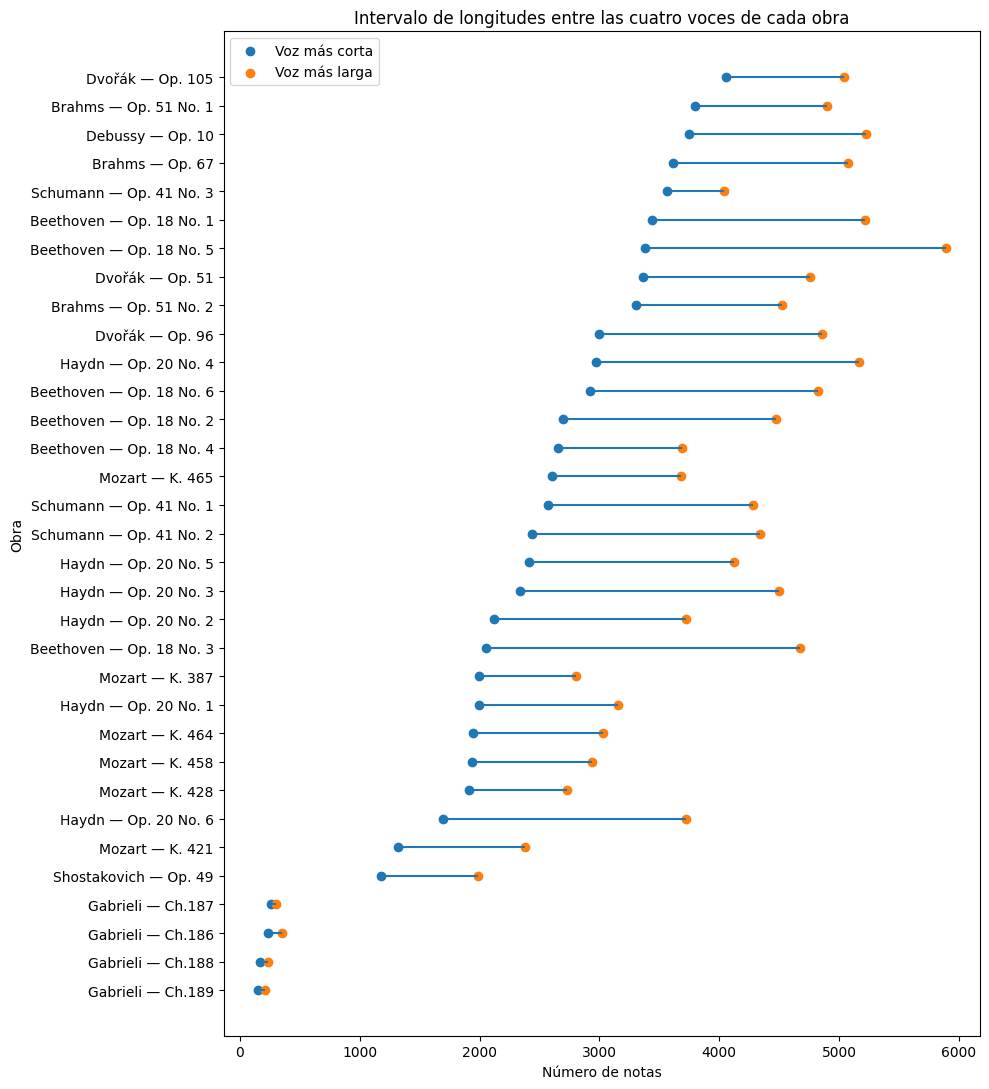

In [13]:
plot_data = work_length_summary.sort_values("min_voice_len")
labels = (
    plot_data["composer"].str.split().str[-1]
    + " — "
    + plot_data["catalogue"].fillna(plot_data["work_title"])
)

y = np.arange(len(plot_data))

plt.figure(figsize=(10, 11))
plt.hlines(
    y=y,
    xmin=plot_data["min_voice_len"],
    xmax=plot_data["max_voice_len"],
)
plt.scatter(plot_data["min_voice_len"], y, label="Voz más corta")
plt.scatter(plot_data["max_voice_len"], y, label="Voz más larga")
plt.yticks(y, labels)
plt.xlabel("Número de notas")
plt.ylabel("Obra")
plt.title("Intervalo de longitudes entre las cuatro voces de cada obra")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Exploración específica de Gabrieli

Cada fila es una canzona completa y no un movimiento extraído de una obra
multimovimiento. Las cuatro secuencias de una fila son las partes completas de
esa canzona.

La corta longitud de estas piezas obliga a utilizar parámetros pequeños para
mPE, Markov, \(C_d\) y \(\gamma\), o bien métodos nulos que preserven la misma
longitud.

voice_role,work_title,catalogue,bass,tenor,upper_1,upper_2
0,Canzon prima 'La Spiritata',Ch.186,235,305,349,344
1,Canzon quarta,Ch.189,151,177,202,209
2,Canzon seconda,Ch.187,259,278,303,299
3,Canzon terza,Ch.188,166,183,238,182


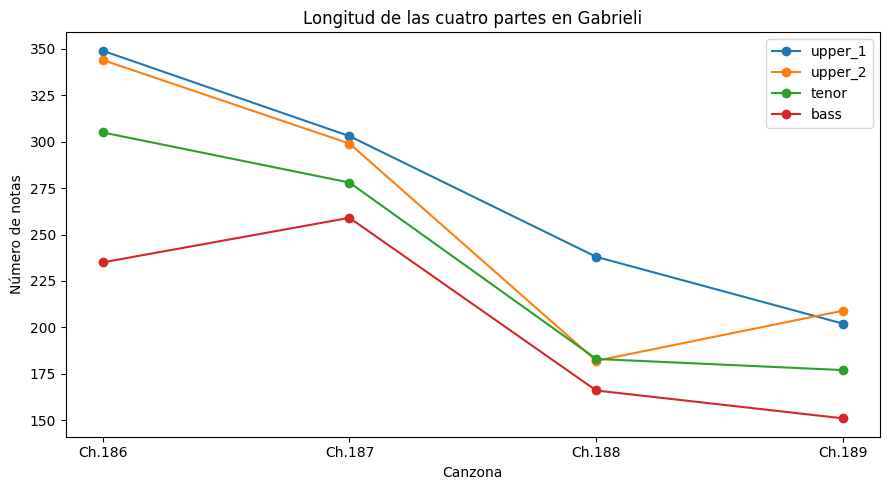

In [14]:
gabrieli_long = voice_lengths[
    voice_lengths["composer"] == "Giovanni Gabrieli"
].copy()

gabrieli_pivot = (
    gabrieli_long.pivot_table(
        index=["work_title", "catalogue"],
        columns="voice_role",
        values="n_notes",
        aggfunc="first"
    )
    .reset_index()
)

display(gabrieli_pivot)

plt.figure(figsize=(9, 5))
for role in gabrieli_roles:
    subset = gabrieli_long[gabrieli_long["voice_role"] == role]
    plt.plot(
        subset["catalogue"],
        subset["n_notes"],
        marker="o",
        label=role,
    )

plt.xlabel("Canzona")
plt.ylabel("Número de notas")
plt.title("Longitud de las cuatro partes en Gabrieli")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Inspección directa de los arrays

Esta celda permite seleccionar una obra y comprobar:

- las primeras alturas;
- la longitud de cada voz;
- el rango MIDI;
- si existe alguna marca de separación.

Como `voices_pitches` es una lista plana de enteros por voz, no existe un símbolo
especial que delimite movimientos. Los cambios de movimiento no pueden
recuperarse solamente a partir de este CSV.

In [30]:
SELECTED_WORK_ID = "debussy_op10"  # Cambiar por cualquier work_id de las tablas

if SELECTED_WORK_ID in set(quartets["work_id"]):
    selected_row = quartets.loc[quartets["work_id"] == SELECTED_WORK_ID].iloc[0]
    selected_roles = quartet_roles
elif SELECTED_WORK_ID in set(gabrieli["work_id"]):
    selected_row = gabrieli.loc[gabrieli["work_id"] == SELECTED_WORK_ID].iloc[0]
    selected_roles = gabrieli_roles
else:
    raise KeyError(f"No existe work_id={SELECTED_WORK_ID!r}")

inspection = []
for role, pitches in zip(selected_roles, selected_row["voices"]):
    inspection.append({
        "voice_role": role,
        "n_notes": len(pitches),
        "first_30_pitches": pitches[:30],
        "midi_min": min(pitches),
        "midi_max": max(pitches),
    })
    print(pitches)

display(pd.DataFrame(inspection))

[67, 65, 62, 65, 68, 70, 68, 67, 65, 67, 62, 62, 70, 67, 70, 67, 70, 74, 70, 67, 70, 67, 70, 74, 79, 77, 74, 77, 80, 82, 80, 79, 77, 79, 74, 75, 77, 75, 74, 71, 72, 68, 70, 68, 67, 65, 67, 62, 68, 70, 68, 67, 65, 67, 62, 65, 68, 70, 68, 67, 65, 67, 62, 65, 67, 62, 65, 67, 62, 74, 74, 79, 77, 79, 81, 79, 74, 74, 74, 79, 77, 79, 81, 79, 74, 75, 74, 72, 70, 72, 70, 72, 74, 75, 74, 75, 77, 79, 77, 79, 80, 82, 80, 82, 84, 86, 84, 82, 80, 82, 80, 79, 77, 79, 77, 75, 74, 75, 74, 72, 70, 72, 70, 72, 74, 75, 74, 75, 77, 79, 77, 79, 80, 82, 80, 82, 84, 86, 84, 82, 80, 82, 80, 79, 77, 79, 77, 75, 74, 75, 74, 75, 77, 79, 77, 75, 74, 75, 74, 75, 74, 75, 74, 72, 70, 72, 70, 72, 74, 75, 74, 72, 70, 72, 70, 68, 67, 68, 69, 70, 67, 68, 69, 70, 74, 73, 72, 71, 70, 69, 68, 67, 74, 73, 72, 71, 70, 69, 68, 67, 79, 78, 77, 76, 75, 74, 73, 72, 79, 78, 77, 76, 75, 74, 73, 72, 67, 66, 65, 64, 63, 62, 61, 60, 67, 66, 65, 64, 63, 62, 61, 60, 67, 65, 62, 65, 68, 70, 68, 67, 65, 67, 62, 63, 68, 65, 66, 63, 63, 65,

,voice_role,n_notes,first_30_pitches,midi_min,midi_max
0,vln_I,3911,"[67, 65, 62, 65, 68, 70, 68, 67, 65, 67, 62, 62, 70, 67, 70, 67, 70, 74, 70, 67, 70, 67, 70, 74, 79, 77, 74, 77, 80,...",55,95
1,vln_II,5133,"[58, 60, 58, 60, 60, 58, 60, 58, 58, 60, 58, 58, 62, 67, 62, 58, 62, 58, 62, 67, 70, 69, 68, 67, 68, 68, 63, 62, 60,...",55,91
2,viola,5225,"[50, 50, 53, 50, 50, 50, 50, 55, 53, 54, 55, 54, 53, 52, 55, 58, 55, 54, 53, 52, 55, 58, 62, 63, 65, 61, 60, 59, 62,...",48,79
3,cello,3747,"[43, 44, 46, 44, 41, 43, 44, 43, 46, 44, 43, 43, 43, 43, 48, 53, 46, 51, 51, 44, 47, 50, 51, 52, 53, 59, 60, 56, 53,...",36,72


## 13. Conclusiones operativas

1. El subcorpus combina **29 cuartetos** y **4 canzonas**, para un total de
   **33 obras y 132 secuencias de voz**.
2. Las obras de cuarteto tienen instrumentación fija:
   violín I, violín II, viola y cello.
3. Gabrieli contiene cuatro partes instrumentales de timbre abierto:
   dos agudas, tenor y bajo.
4. Cada fila de `quartet_subcorpus_works.csv` representa una obra completa.
   En las obras originalmente separadas por movimiento, los arrays fueron
   concatenados sin delimitadores.
5. Cada fila de Gabrieli representa una canzona completa de un solo movimiento.
6. Las canzonas son mucho más cortas que los cuartetos. Para compararlas se
   recomiendan ventanas de 128 o 256 notas y parámetros de baja dimensión.
7. La reproducción de una voz a partir de `voices_pitches` conserva alturas y
   orden, pero no el ritmo original.